# Preprocesamiento y Acondicionamiento del Dataset Final 

Este cuaderno tiene como objetivo construir el conjunto de datos definitivo para la fase de combinación y modelado multivariado. Partiendo de las conclusiones obtenidas en la fase exploratoria anterior, se aplican los filtros de universo aprobados y se implementa el pipeline de preprocesamiento sobre las señales seleccionadas (momentum_12_1, upside_volatility y amihud_illiquidity).

El procedimiento de acondicionamiento transforma las señales crudas mediante dos etapas clave ejecutadas de forma transversal (cross-sectional) por fecha:

- **Tratamiento de asimetría y outliers**: Transformación logarítmica de la iliquidez de Amihud y winsorización al $1\%-99\%$ para controlar valores extremos sin destruir la estructura del ranking.

- **Estandarización transversal**: Normalización mediante Z-score diario ($\mu=0, \sigma=1$) para homogenizar escalas entre distintas familias de riesgo, tendencia y liquidez.

El resultado final es un dataset limpio, acotado y libre de redundancias, listo para alimentar los modelos cuantitativos.

In [44]:
import sys
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Objective & Load Data
Objetivo del notebook.
Carga de los factores desde data/processed/.
Carga de prices (si lo necesitas para alguna comprobación).

In [2]:
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

# potential style factors
momentum_12_1 = pd.read_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal = pd.read_parquet("../data/processed/short_term_reversal.parquet")
rolling_volatility = pd.read_parquet("../data/processed/rolling_volatility.parquet")
upside_volatility = pd.read_parquet("../data/processed/upside_volatility.parquet")
downside_volatility = pd.read_parquet("../data/processed/downside_volatility.parquet")
amihud_illiquidity = pd.read_parquet("../data/processed/amihud_illiquidity.parquet")

## 2. Apply Universe Decisions

En esta seccion se aplican de forma explicita las reglas de negocio y criterios de filtrado aprobados en la fase exploratoria anterior sobre el dataset de factores crudos. Con el fin de garantizar la calidad e integridad del panel antes del preprocesamiento, se ejecutan dos decisiones estructurales sobre el universo:

- **Exclusion de activos problematicos**: Se eliminan del panel los tickers SW y AMCR debido a inconsistencias historicas severas asociadas a eventos corporativos de fusion y reconstruccion sintetica de datos.

- **Acortamiento del periodo inicial (warm-up)**: Se descartan las primeras 252 sesiones bursatiles del dataset. Esta medida asegura que todas las variables calculadas mediante ventanas moviles de largo plazo (como el momentum de 12 meses) cuenten con datos plenamente definidos y libres de sesgos de inicializacion.


### 2.1 Universe Filtering

In [3]:
tickers_to_remove = ["SW", "AMCR"]

prices = prices.drop(
    columns=tickers_to_remove, level=1, errors="ignore"
)

momentum_12_1 = momentum_12_1.drop(columns=tickers_to_remove)
short_term_reversal = short_term_reversal.drop(columns=tickers_to_remove)
rolling_volatility = rolling_volatility.drop(columns=tickers_to_remove)
upside_volatility = upside_volatility.drop(columns=tickers_to_remove)
downside_volatility = downside_volatility.drop(columns=tickers_to_remove)
amihud_illiquidity = amihud_illiquidity.drop(columns=tickers_to_remove)

### 2.2 Analysis Period

In [4]:
analysis_start_date = prices.index[252]

prices_clean = prices.loc[analysis_start_date:]

momentum_12_1 = momentum_12_1.loc[analysis_start_date:]
short_term_reversal = short_term_reversal.loc[analysis_start_date:]
rolling_volatility = rolling_volatility.loc[analysis_start_date:]
upside_volatility = upside_volatility.loc[analysis_start_date:]
downside_volatility = downside_volatility.loc[analysis_start_date:]
amihud_illiquidity = amihud_illiquidity.loc[analysis_start_date:]

### 2.3 Factor Selection

Una vez aplicado el filtro de activos e inicio del periodo temporal, se procede a reducir el panel de datos conservando unicamente los tres factores seleccionados en la fase exploratoria:

- 12-1 Momentum (momentum_12_1)

- Upside Volatility (upside_volatility)

- Log10 Amihud (amihud_illiquidity, sobre el que se aplicara la transformacion logaritmica en la siguiente fase)

Se descartan el resto de senales evaluadas por redundancia o bajo poder predictivo. Al finalizar este paso, el dataset queda acotado a las dimensiones definitivas del universo de estudio tanto en numero de activos como en numero de variables explicativas.

## 3. Winsorization

### 3.1 Methodology

En esta etapa se implementa el tratamiento de valores extremos (outliers) sobre las tres señales seleccionadas. Con el fin de evitar que observaciones distorsionadas aplasten la distribución de los factores o alteren indebidamente el ajuste de los modelos, se aplica una técnica de winsorización. El proceso se rige por dos criterios metodológicos fundamentales:

- **Enfoque transversal diario (cross-sectional)**: La winsorización se ejecuta fecha a fecha de forma independiente sobre el conjunto de activos disponible en cada sesión. Esto previene el sesgo de supervivencia y respeta los distintos regímenes de mercado, garantizando que un valor extremo en un día de alta volatilidad no se evalúe con el mismo rasero que en un periodo de calma.

- **Umbrales de acotamiento (percentiles 1% y 99%)**: Se adopta el estándar habitual en literatura cuantitativa de renta variable, fijando los límites en los percentiles 1 y 99 diarios. Las observaciones situadas por debajo del percentil 1 o por encima del percentil 99 no se eliminan del panel, sino que se reemplazan (suavizan) por el valor exacto de dicho umbral, preservando la ordenación (ranking) relativa de los activos sin perder observaciones.

### 3.2 Apply log10 to Amihud Illiquidity

Antes de tratar los valores extremos, aplicamos una transformación logarítmica ($\log_{10}$) a la iliquidez de Amihud para corregir su fuerte asimetría a la derecha. La variable cruda acumula casi todas sus observaciones muy cerca de cero y despliega una cola extremadamente larga por días o activos de baja negociación. 

El paso a escala logarítmica suaviza esa compresión, aproxima el factor a una distribución simétrica y facilita una winsorización transversal mucho más limpia sin alterar el orden relativo de los activos.

In [12]:
# Apply log10 transformation only to positive values
log10_amihud = np.log10(
    amihud_illiquidity.where(amihud_illiquidity > 0)
)

### 3.3 Apply Winsorization

In [33]:
from src.preprocessing.factor_preprocessing import winsorize_cross_sectional

# 1. Combine factor series into a single panel DataFrame
factor_matrix = (
    pd.concat(
        {
            "momentum_12_1": momentum_12_1.stack(),
            "upside_volatility": upside_volatility.stack(),
            "log10_amihud": log10_amihud.stack(),
        },
        axis=1,
    )
    .rename_axis(["date", "ticker"])
    .reset_index()
)

# 2. Define target factor columns for cross-sectional clipping
factor_cols = [
    "momentum_12_1",
    "upside_volatility",
    "log10_amihud",
]

# 3. Apply cross-sectional winsorization (1% - 99%)
df_win = winsorize_cross_sectional(
    factor_matrix, 
    cols=factor_cols, 
    p_low=0.01, 
    p_high=0.99
)

# 4. Set (date, ticker) as multi-index to remove numeric index
df_win = df_win.set_index(["date", "ticker"])

factor_matrix = factor_matrix.set_index(["date", "ticker"])

### 3.3 Validation

Para verificar la correcta ejecución de la winsorización y evaluar su impacto en las distribuciones, se realiza una validación comparativa entre los factores originales y sus versiones acotadas (*_win).

El objetivo es confirmar que el tratamiento elimina los valores extremos sin distorsionar la estructura general del dataset, evaluando la proporción de observaciones ajustadas en las colas y la compresión del rango dinámico de cada variable.

Comparar antes/después.

Yo haría algo sencillo:

porcentaje de outliers antes
porcentaje de outliers después
histograma antes/después de cada factor

No hace falta repetir todo el análisis del notebook 04.

In [30]:
validation_stats = []

for col in factor_cols:
    orig = df_win[col]
    win = df_win[f"{col}_win"]
    
    # a value has been clipped if the original value is not equal to the winsorized value
    clipped = ~(orig == win)
    pct_clipped = clipped.mean() * 100
    
    validation_stats.append({
        "factor": col,
        "orig_min": orig.min(),
        "win_min": win.min(),
        "orig_max": orig.max(),
        "win_max": win.max(),
        "pct_clipped (%)": pct_clipped
    })

df_validation = (
    pd.DataFrame(validation_stats)
    .set_index("factor")
)
display(df_validation.style.format("{:.3g}"))

,orig_min,win_min,orig_max,win_max,pct_clipped (%)
factor,,,,,
momentum_12_1,-0.98,-0.837,11.5,5.22,8.42
upside_volatility,0.00232,0.00384,0.0928,0.0514,7.56
log10_amihud,-12.4,-11.8,-6.14,-7.7,7.45


Al analizar los resultados del proceso de winsorización, se confirma una reducción efectiva de los valores extremos en los tres factores sin alterar la estructura central del dataset.

En el caso de momentum_12_1, el impacto es especialmente visible en la cola superior, donde el valor máximo original de 11.5 —un dato atípico equivalente a una rentabilidad desproporcionada del 1150%— queda acotado en 5.22, mientras que el mínimo se suaviza levemente de -0.98 a -0.837. Para upside_volatility, el techo de la distribución se comprime de 0.0928 a 0.0514, eliminando los picos aislados de volatilidad. Por su parte, en log10_amihud los extremos de ambas colas se reajustan de forma equilibrada, elevando el mínimo de -12.4 a -11.8 y conteniendo el máximo de -6.14 en -7.7.

El porcentaje de observaciones ajustadas se sitúa en un 8.42% para el momentum, un 7.56% para la volatilidad al alza y un 7.45% para la iliquidez de Amihud. Que estas proporciones globales ronden entre el 7% y el 8% es un comportamiento técnicamente esperado y correcto. Al calcular los umbrales del 1% y 99% de manera transversal día a día (cross-sectional) en lugar de hacerlo de forma estática sobre toda la muestra histórica, el filtro se adapta de forma dinámica a la dispersión diaria del mercado. Esto permite neutralizar los outliers relativos de cada fecha concreta antes de proceder a la estandarización Z-score.

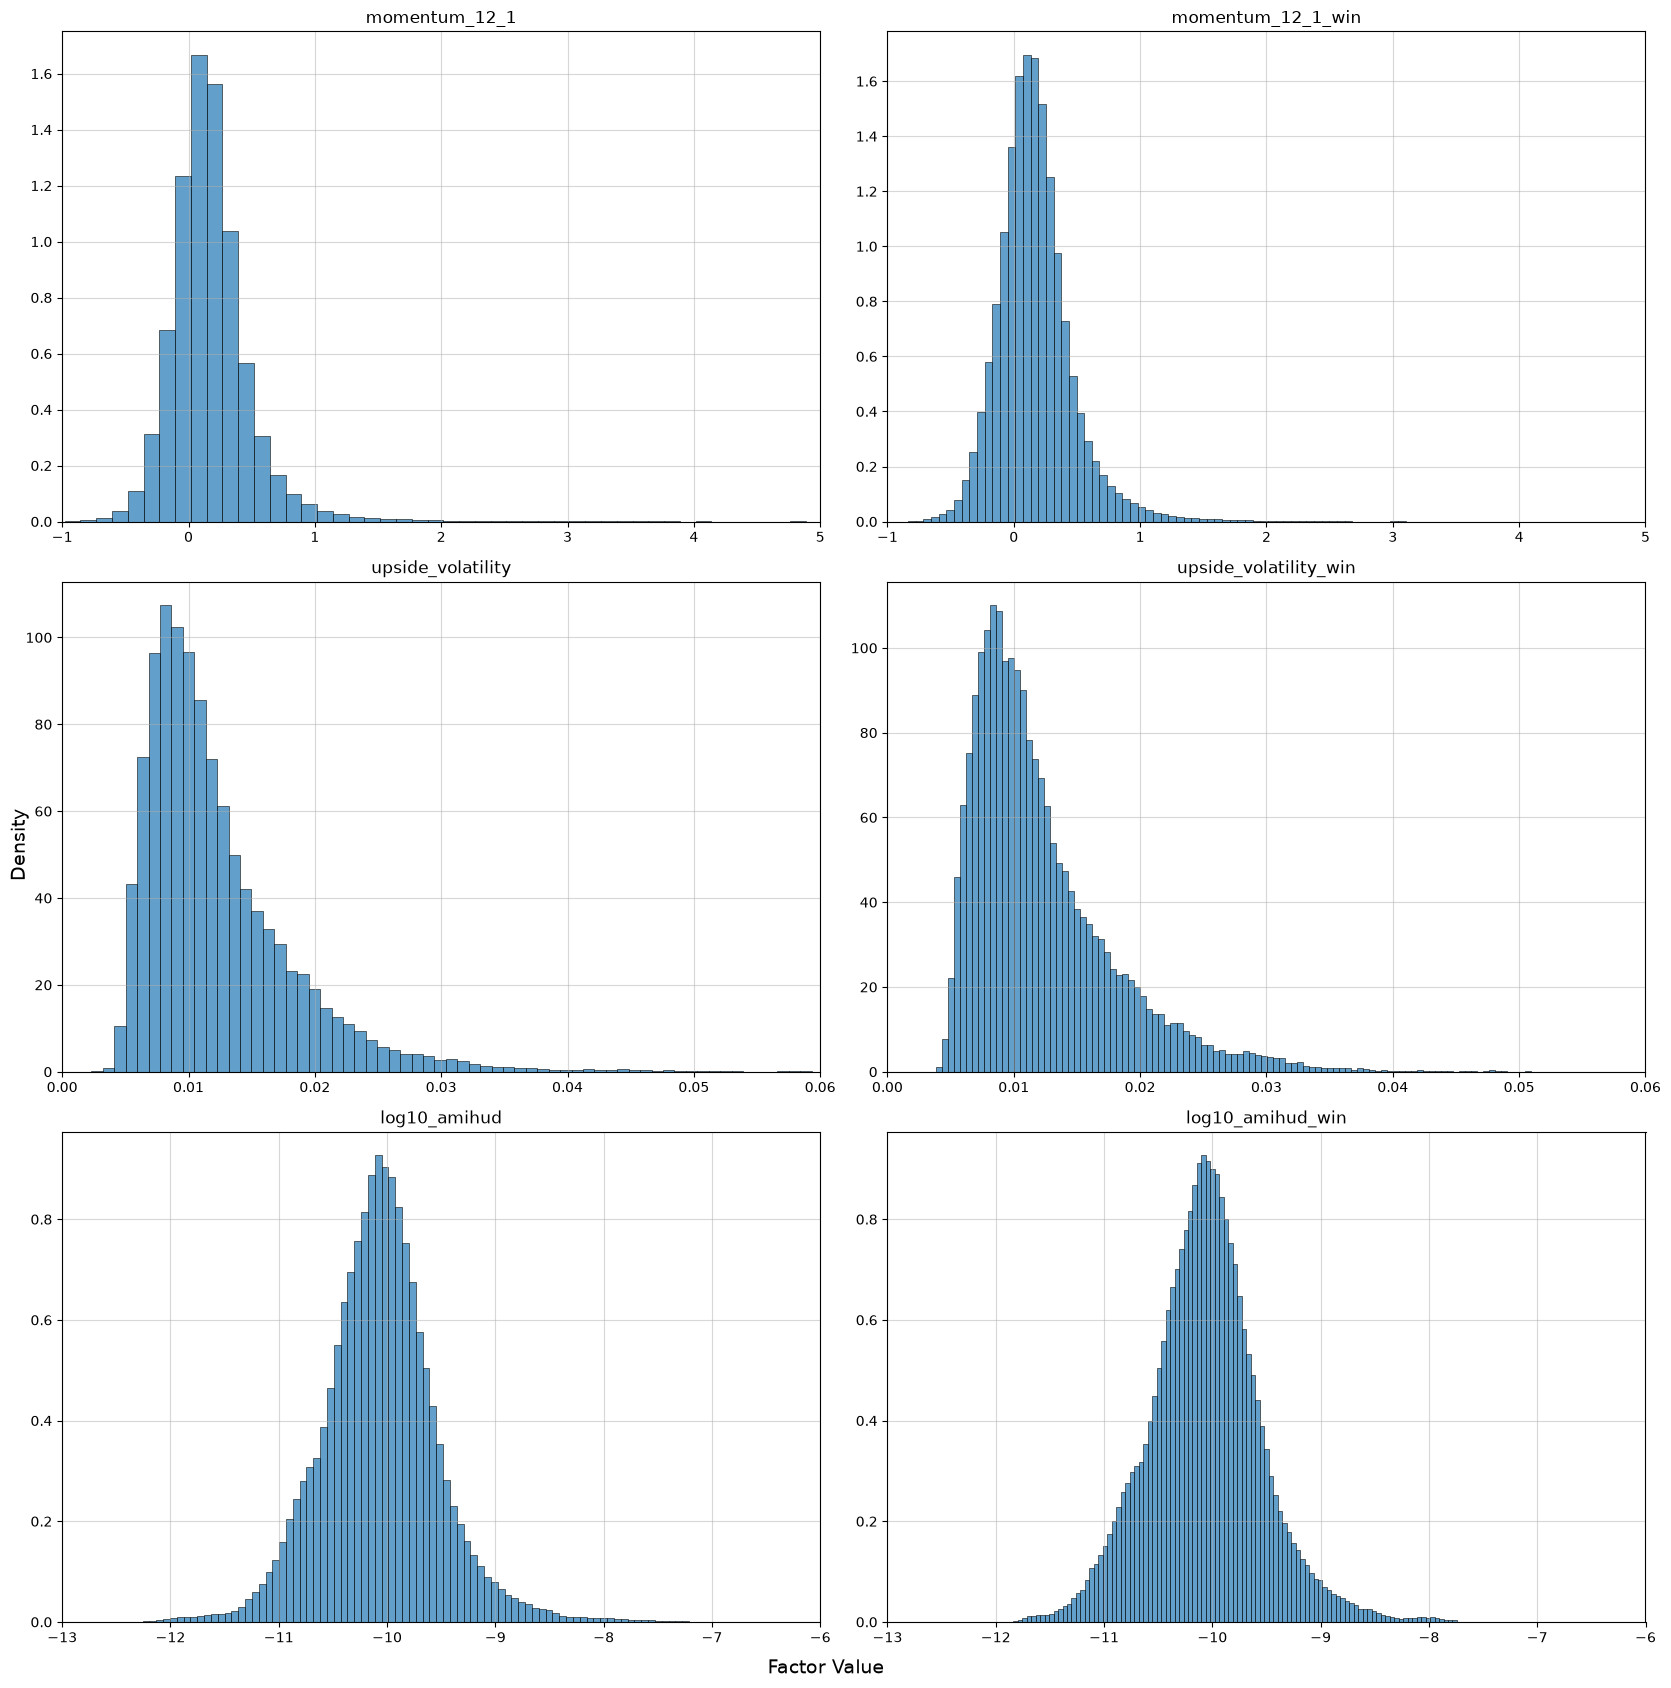

In [43]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(17, 17),
)
axes = axes.flatten()

factor_cols_plot = [
    "momentum_12_1",
    "momentum_12_1_win",
    "upside_volatility",
    "upside_volatility_win",
    "log10_amihud",
    "log10_amihud_win"
    
]

for ax, col in zip(axes, factor_cols_plot):

    values = df_win[col].dropna()

    sns.histplot(
        values,
        bins=100,
        kde=False,
        stat="density",
        edgecolor="black",
        alpha=0.7,
        ax=ax
    )

    ax.set_title(col, fontsize=12)
    ax.grid(alpha=0.5)
    ax.set_ylabel("")
    ax.set_xlabel("")

# Momentum
axes[0].set_xlim(-1, 5)
axes[1].set_xlim(-1, 5)

# Upside Volatility
axes[2].set_xlim(0, 0.06)
axes[3].set_xlim(0, 0.06)

# Log10 Amihud
axes[4].set_xlim(-13, -6)
axes[5].set_xlim(-13, -6)

fig.supxlabel("Factor Value", fontsize=14)
fig.supylabel("Density", fontsize=14)

plt.tight_layout()
plt.show()

La comparación gráfica entre las distribuciones originales y las acotadas confirma el efecto deseado del clipping transversal. Aunque la masa central mantiene la misma altura e inclinación principal, las versiones _win se muestran visiblemente más estrechas, lo que refleja la eliminación de las colas extremas y la compresión del rango dinámico global.

El fenómeno visible en el gráfico —donde el histograma acotado parece tener mayor densidad de barras utilizando el mismo número de bins (bins=100)— se debe al ajuste automático del ancho de los intervalos. En la distribución original, la presencia de unos pocos datos desproporcionadamente lejanos obligaba a extender el eje horizontal sobre un rango enorme (por ejemplo, hasta 11.5 en el momentum), provocando que los 100 intervalos quedaran dispersos a lo largo de un espacio muy amplio y desierto. Al recortar las colas extremas mediante la winsorización, ese mismo número de intervalos se distribuye en un rango mucho más estrecho, aumentando la resolución visual en la zona central donde se concentran los datos.

Además, se observan picos acumulativos en los extremos exactos de cada distribución winsorizada, correspondientes a las observaciones que superaban los umbrales diarios del 1% y 99% y que han sido reasignadas a dichos límites.

## 4. Cross-Sectional Standardization

Una vez tratados los valores extremos mediante la winsorización, el siguiente paso en el pipeline es la estandarización transversal de los factores. En este apartado se transforma la escala de cada variable para que, en cada fecha de negociación, los factores sean directamente comparables entre sí y presenten una distribución uniforme a lo largo del universo de activos.

### 4.1 Methodology

La estandarización Z-score transversal transforma cada factor en cada fecha $t$ de forma independiente, restando su media y dividiendo por su desviación típica entre todos los activos disponibles ese día:

$$z_{i,t} = \frac{x_{i,t} - \mu_t}{\sigma_t}$$

donde $\mu_t$ y $\sigma_t$ son la media y la desviación típica del factor en el día $t$.

Esta transformación garantiza que, en cada fecha de negociación, cada factor tenga media cero ($\mu_t = 0$) y desviación típica uno ($\sigma_t = 1$), haciendo comparable la magnitud de variables con diferentes unidades de medida a lo largo del panel.

### 4.2 Apply Z-score

Aplicarlo diariamente.

In [50]:
from src.preprocessing.factor_preprocessing import standardize_cross_sectional

win_cols = [f"{col}_win" for col in factor_cols]

df_z = standardize_cross_sectional(
    df_win,
    cols=win_cols
)

### 4.3 Validation

In [53]:
z_cols = [f"{col}_z" for col in win_cols]

# Group by date to check daily properties
daily_stats = (
    df_z
    .groupby("date")[z_cols]
    .agg(["mean", "std"])
)

# Display min and max across all dates to verify convergence to 0 and 1
validation_summary = []
for col in z_cols:
    validation_summary.append({
        "factor": col,
        "max_abs_daily_mean": daily_stats[(col, "mean")].abs().max(),
        "min_daily_std": daily_stats[(col, "std")].min(),
        "max_daily_std": daily_stats[(col, "std")].max()
    })


pd.DataFrame(validation_summary).set_index("factor")

,max_abs_daily_mean,min_daily_std,max_daily_std
factor,,,
momentum_12_1_win_z,2.172275e-16,1.0,1.0
upside_volatility_win_z,6.866338e-16,1.0,1.0
log10_amihud_win_z,4.422910e-15,1.0,1.0


Para verificar la correcta aplicación de la estandarización Z-score, se analiza el comportamiento transversal de los factores ajustados en cada fecha de negociación del dataset.

La comprobación cuantitativa confirma una convergencia exacta con las propiedades teóricas requeridas. El valor máximo de la media diaria absoluta se sitúa en el orden de $10^{-15}$ y $10^{-16}$ para todos los factores —alcanzando un máximo de $2.17 \times 10^{-16}$ en momentum_12_1_z, $6.87 \times 10^{-16}$ en upside_volatility_z y $4.42 \times 10^{-15}$ en log10_amihud_z—. Estas diferencias son simples desviaciones de precisión numérica en coma flotante, lo que confirma que la media diaria de cada factor es cero en todo el periodo histórico.

Por su parte, la dispersión transversal diaria se mantiene rigurosamente constante. Tanto la desviación típica mínima como la máxima a lo largo de todas las fechas registradas son exactamente igual a $1.0$ para los tres factores.

Estos resultados verifican que la transformación neutraliza con precisión los cambios de escala e intensidad de la volatilidad temporal, garantizando que los factores sean directamente comparables entre sí en cualquier fecha de negociación.

## 5. Final Dataset Validation

Un pequeño sanity check.

Por ejemplo:

número de activos
rango temporal
NaNs
dimensiones
nombres de factores

Muy parecido al estilo del notebook 02, pero mucho más corto.

Check de alineación del objetivo ($t+21$): Asegurarte de que tras aplicar el Winsorize y el Z-score a los factores, el retorno futuro (return_21d) no ha sido alterado ni estandarizado (el objetivo debe mantenerse en su escala real de rentabilidad).


## 6. Export Preprocessed Dataset

Nos guardamos en .parquet los tres factores y la factor matrix. Los prices, retornos y retornos a futuro tenemos que ver si van a ser utiles. 